In [ ]:
# Cell 1 — Install dependencies
!pip install ultralytics opencv-python pandas


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive"

 17491237056674837552505831388117.jpg  'DEEP_s_Resume AI&ML (1)-1.pdf'
 AdmitCard-260410853562_copy.pdf       'DEEP_s_Resume AI&ML.pdf'
'Adobe Scan Apr 16, 2026.pdf'	       'Fee Deep 4th sem Samarth eGov.pdf'
 Certificate.pdf		        Garbage_Detection.ipynb
'Colab Notebooks'		        garbage_Detection.pt
 Deep_Resume-1.pdf		        Garbage_My_Dataset.yolov8.zip
 Deep_Resume.pdf		        Garbage_V1.mp4
'DEEP_s_Resume AI&ML (1)-1 (1).pdf'    'Maths for DSA and CP.gdoc'
'DEEP_s_Resume AI&ML (1)-1 (2).pdf'     Pothole_Detection.ipynb
'DEEP_s_Resume AI&ML (1)-1 (3).pdf'     Synopsis.pdf


In [ ]:
import cv2
import os
import json
import pandas as pd
from datetime import datetime
from ultralytics import YOLO
from google.colab import files

In [ ]:
# Cell 5 — Configuration & Paths
# ── File paths ────────────────────────────────────────────────────────────────
MODEL_PATH        = "/content/drive/MyDrive/garbage_Detection.pt"
VIDEO_PATH        = "/content/drive/MyDrive/WhatsApp Video 2026-06-04 at 11.41.50 AM.mp4"
SAVE_DIR          = "/content/Garbage_GPS_DIS"
OUTPUT_VIDEO_RAW  = f"{SAVE_DIR}/output_raw.mp4"
OUTPUT_VIDEO_H264 = f"{SAVE_DIR}/output_video.mp4"
CROSSED_FRAME_DIR = f"{SAVE_DIR}/crossed_frames"

os.makedirs(SAVE_DIR,          exist_ok=True)
os.makedirs(CROSSED_FRAME_DIR, exist_ok=True)

# ── Detection settings ────────────────────────────────────────────────────────
CONF = 0.25

# ── Distance estimation ───────────────────────────────────────────────────────
KNOWN_OBJECT_HEIGHT = 0.5   # real-world height of object in metres
FOCAL_LENGTH        = 800   # tune for your camera

# ── GPS (static) ──────────────────────────────────────────────────────────────
CURRENT_LAT = 26.8467
CURRENT_LON = 80.9462

# ── Counting line (fraction of frame height) ──────────────────────────────────
LINE_RATIO = 0.70

print("✓ Config ready")
print(f"  Model         : {MODEL_PATH}")
print(f"  Video         : {VIDEO_PATH}")
print(f"  Output video  : {OUTPUT_VIDEO_H264}")
print(f"  Crossed frames: {CROSSED_FRAME_DIR}")


✓ Config ready
  Model         : /content/drive/MyDrive/garbage_Detection.pt
  Video         : /content/drive/MyDrive/WhatsApp Video 2026-06-04 at 11.41.50 AM.mp4
  Output video  : /content/Garbage_GPS_DIS/output_video.mp4
  Crossed frames: /content/Garbage_GPS_DIS/crossed_frames


In [ ]:
# Cell 6 — Load YOLO model
model = YOLO(MODEL_PATH)
print("✓ Model loaded")


✓ Model loaded


In [ ]:
# Cell 7 — Open video and set up VideoWriter
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_PATH}")

fps_in = cap.get(cv2.CAP_PROP_FPS) or 25.0
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
LINE_Y = int(height * LINE_RATIO)

print(f"✓ Video opened")
print(f"  Resolution : {width} x {height}")
print(f"  FPS        : {fps_in:.1f}")
print(f"  Frames     : {total}")
print(f"  Line Y     : {LINE_Y}  ({LINE_RATIO*100:.0f}% of height)")

writer = cv2.VideoWriter(
    OUTPUT_VIDEO_RAW,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps_in,
    (width, height)
)
print(f"✓ VideoWriter ready → {OUTPUT_VIDEO_RAW}")


✓ Video opened
  Resolution : 478 x 850
  FPS        : 30.0
  Frames     : 270
  Line Y     : 595  (70% of height)
✓ VideoWriter ready → /content/Garbage_GPS_DIS/output_raw.mp4


In [ ]:
# Cell 8 — Initialise tracking state
# Run this cell to reset count before starting detection
records      = []
frame_id     = 0
count        = 0        # cumulative crossing count — only ever goes UP
crossed_ids  = set()    # IDs already counted — prevents double counting
prev_centers = {}       # stores last known cy per tracked object ID

print("✓ Tracking state reset")
print(f"  count       = {count}")
print(f"  crossed_ids = {crossed_ids}")


✓ Tracking state reset
  count       = 0
  crossed_ids = set()


In [ ]:
# Cell 9 — Run detection loop
print(f"Starting detection on {total} frames...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    timestamp_ms = cap.get(cv2.CAP_PROP_POS_MSEC)

    # ── Run YOLO tracking ─────────────────────────────────────────────────────
    results   = model.track(frame, persist=True, conf=CONF, verbose=False)
    annotated = results[0].plot()
    boxes     = results[0].boxes

    # ── Draw counting line ────────────────────────────────────────────────────
    cv2.line(annotated, (0, LINE_Y), (width, LINE_Y), (0, 255, 255), 3)

    # ── Process each detected object ──────────────────────────────────────────
    if len(boxes) and boxes.id is not None:
        ids    = boxes.id.cpu().numpy()
        coords = boxes.xyxy.cpu().numpy()

        for box, obj_id in zip(coords, ids):
            x1, y1, x2, y2 = box
            cy = int((y1 + y2) / 2)

            pixel_height = max(1, y2 - y1)
            distance     = (KNOWN_OBJECT_HEIGHT * FOCAL_LENGTH) / pixel_height

            crossed = False
            prev_y  = prev_centers.get(obj_id, cy)

            # Count crossing — object moves downward through LINE_Y
            if prev_y < LINE_Y <= cy and obj_id not in crossed_ids:
                crossed_ids.add(obj_id)
                count  += 1
                crossed = True

                # Save snapshot of this crossing event
                snap = f"crossed_{count:04d}_f{frame_id:06d}.jpg"
                cv2.imwrite(os.path.join(CROSSED_FRAME_DIR, snap), annotated)

            prev_centers[obj_id] = cy

            records.append({
                "frame_id":      frame_id,
                "object_id":     int(obj_id),
                "crossed":       crossed,
                "count":         count,
                "timestamp_sec": round(timestamp_ms / 1000, 2),
                "gps_lat":       CURRENT_LAT,
                "gps_lon":       CURRENT_LON,
                "distance_m":    round(float(distance), 2),
            })

    # ── Draw count overlay (AFTER crossing check — always shows correct number)
    text = f"Count: {count}"
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)
    pad = 12
    rx1 = width - tw - pad * 2 - 10
    ry1 = 10
    rx2 = width - 10
    ry2 = th + pad * 2 + 10
    cv2.rectangle(annotated, (rx1, ry1), (rx2, ry2), (0, 0, 0),       -1)  # black bg
    cv2.rectangle(annotated, (rx1, ry1), (rx2, ry2), (0, 255, 255),    2)  # cyan border
    cv2.putText(annotated, text, (rx1 + pad, ry2 - pad),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2, cv2.LINE_AA)

    # ── Write frame directly to video ─────────────────────────────────────────
    writer.write(annotated)
    frame_id += 1

    if frame_id % 100 == 0:
        print(f"  {frame_id}/{total} frames  |  count = {count}")

cap.release()
writer.release()

print(f"\n✓ Detection complete")
print(f"  Frames processed : {frame_id}")
print(f"  Final count      : {count}")
print(f"  Raw video saved  → {OUTPUT_VIDEO_RAW}")


Starting detection on 270 frames...
  100/270 frames  |  count = 2
  200/270 frames  |  count = 7

✓ Detection complete
  Frames processed : 270
  Final count      : 8
  Raw video saved  → /content/Garbage_GPS_DIS/output_raw.mp4


In [ ]:
# Cell 10 — Re-encode to H.264 for smooth playback
# mp4v from OpenCV stutters in Colab — ffmpeg fixes this in seconds
!ffmpeg -y -i "{OUTPUT_VIDEO_RAW}" \
        -vcodec libx264 -crf 23 -preset fast \
        -pix_fmt yuv420p \
        "{OUTPUT_VIDEO_H264}" \
        -loglevel error

size_mb = os.path.getsize(OUTPUT_VIDEO_H264) / 1e6
print(f"✓ H.264 video ready → {OUTPUT_VIDEO_H264}  ({size_mb:.1f} MB)")


✓ H.264 video ready → /content/Garbage_GPS_DIS/output_video.mp4  (2.5 MB)


In [ ]:
# Cell 11 — Preview output video inline
from IPython.display import Video
Video(OUTPUT_VIDEO_H264, embed=True, width=700)


In [ ]:
# Cell 12 — Re-encode to H.264 for smooth playback
!ffmpeg -y -i "{OUTPUT_VIDEO_RAW}" \
        -vcodec libx264 -crf 23 -preset fast \
        -pix_fmt yuv420p \
        "{OUTPUT_VIDEO_H264}" \
        -loglevel error

size_mb = os.path.getsize(OUTPUT_VIDEO_H264) / 1e6
print(f"H.264 video ready -> {OUTPUT_VIDEO_H264}  ({size_mb:.1f} MB)")


H.264 video ready -> /content/Garbage_GPS_DIS/output_video.mp4  (2.5 MB)


In [ ]:
# Cell 12 — Save detection records to CSV and JSON
csv_path  = f"{SAVE_DIR}/detections.csv"
json_path = f"{SAVE_DIR}/detections.json"

cleaned = []
for r in records:
    c = r.copy()
    c["distance_m"] = float(c["distance_m"])
    cleaned.append(c)

pd.DataFrame(cleaned).to_csv(csv_path, index=False)

with open(json_path, "w") as f:
    json.dump(cleaned, f, indent=4)

print(f"✓ Saved {len(cleaned)} records")
print(f"  CSV  → {csv_path}")
print(f"  JSON → {json_path}")


✓ Saved 347 records
  CSV  → /content/Garbage_GPS_DIS/detections.csv
  JSON → /content/Garbage_GPS_DIS/detections.json


In [ ]:
# Cell 13 — Preview detection records
df = pd.read_csv(csv_path)
print(f"Total rows : {len(df)}")
print(f"Unique IDs : {df['object_id'].nunique()}")
print(f"Crossings  : {df['crossed'].sum()}")
df.head(20)


Total rows : 347
Unique IDs : 24
Crossings  : 8


,frame_id,object_id,crossed,count,timestamp_sec,gps_lat,gps_lon,distance_m
0,0,1,False,0,0.00,26.8467,80.9462,2.26
1,0,2,False,0,0.00,26.8467,80.9462,3.66
2,0,3,False,0,0.00,26.8467,80.9462,3.02
3,1,1,False,0,0.03,26.8467,80.9462,2.18
4,1,2,False,0,0.03,26.8467,80.9462,4.00
5,1,3,False,0,0.03,26.8467,80.9462,3.30
6,2,2,False,0,0.07,26.8467,80.9462,3.57
7,3,2,False,0,0.10,26.8467,80.9462,4.13
8,12,16,False,0,0.40,26.8467,80.9462,4.33
9,16,16,False,0,0.53,26.8467,80.9462,4.48


Crossing snapshots saved: 31


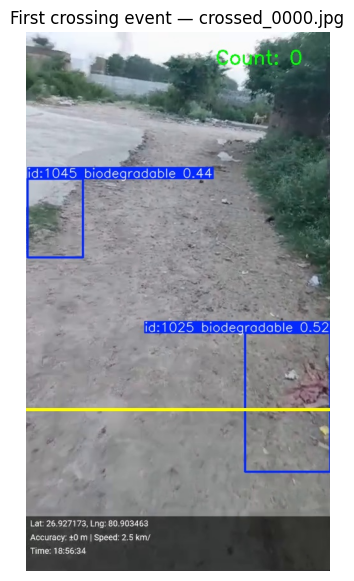

In [ ]:
# Cell 14 — Preview a crossing-event snapshot
import matplotlib.pyplot as plt
from PIL import Image

snaps = sorted(os.listdir(CROSSED_FRAME_DIR))
print(f"Crossing snapshots saved: {len(snaps)}")

if snaps:
    img = Image.open(os.path.join(CROSSED_FRAME_DIR, snaps[0]))
    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.title(f"First crossing event — {snaps[0]}")
    plt.axis("off")
    plt.show()
else:
    print("No crossings detected. Try lowering CONF or adjusting LINE_RATIO in Cell 5.")


In [ ]:
# Cell 15 — Download all outputs
from google.colab import files

print("Downloading video...")
files.download(OUTPUT_VIDEO_H264)

print("Downloading CSV...")
files.download(csv_path)

print("Downloading JSON...")
files.download(json_path)

print("Zipping crossing snapshots...")
!zip -r /content/crossed_frames.zip "{CROSSED_FRAME_DIR}" -q
files.download("/content/crossed_frames.zip")

print("✓ All downloads started")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zipping crossing snapshots...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All downloads started
